## Portfolio Tracker

Collects client details interactively (input/float), fetches live stock prices via yfinance, values the whole portfolio, and prints a personalised summary sentence for the client.

In [1]:
import yfinance as yf
import os
import matplotlib.pyplot as plt
from datetime import datetime
import json

DATA_FILE = "client_data.json"

In [2]:
def naira(amount):
    return f"₦{amount:,.2f}"

In [3]:
def get_stock_holdings():
    """Ask the client for each stock ticker + shares held, fetch live price."""
    holdings = []
    n = int(input("How many different stocks does the client hold? "))
    for i in range(n):
        print(f"\n-- Stock {i + 1} --")
        ticker = input("Ticker symbol (e.g. AAPL, DANGCEM.LG): ").strip().upper()
        shares = float(input(f"Number of shares held in {ticker}: "))
 
        try:
            data = yf.Ticker(ticker).history(period="1d")
            price = float(data["Close"].iloc[-1])
        except Exception:
            print(f"Could not fetch a live price for {ticker}; enter it manually.")
            price = float(input(f"Manual current price for {ticker}: "))
 
        market_value = shares * price
        holdings.append({ "ticker": ticker, "shares": shares, "price": price, "market_value": market_value,})
        print(f"{ticker}: {shares} shares @ {naira(price)} = {naira(market_value)}")
 
    return holdings

In [4]:
def collect_client_inputs():
    print(" Client Portfolio Intake \n")
    name = input("Investor Name: ").strip()
    inv_date = input("Investment Date (e.g. 31-Dec-26): ").strip()
 
    stock_holdings = get_stock_holdings()
    stock_value = sum(h["market_value"] for h in stock_holdings)
 
    print("\n Other Asset Classes ")
    tbill_value = float(input("Treasury Bills amount invested (₦): "))
    mf_value = float(input("Mutual Funds amount invested (₦): "))
    cash_value = float(input("Cash amount (₦): "))
 
    print("\n Expected Returns ")
    stock_return = float(input("Expected Annual Stock Return (%): ")) / 100
    tbill_rate = float(input("Treasury Bill Rate (%): ")) / 100
    mf_return = float(input("Mutual Fund Return (%): ")) / 100
    cash_rate = float(input("Cash Interest Rate (%): ")) / 100
 
    print("\n Volatility ")
    stock_vol = float(input("Stock Volatility (%): ")) / 100
    mf_vol = float(input("Mutual Fund Volatility (%): ")) / 100
    tbill_vol = float(input("Treasury Bill Volatility (%): ")) / 100
 
    risk_free_rate = float(input("\nRisk-Free Rate (%): ")) / 100
 
    return { "name": name, "date": inv_date, "stock_holdings": stock_holdings,
        "values": {"Stocks": stock_value, "Treasury Bills": tbill_value, "Mutual Funds": mf_value, "Cash": cash_value,},
        "returns": { "Stocks": stock_return, "Treasury Bills": tbill_rate, "Mutual Funds": mf_return, "Cash": cash_rate,},
        "volatility": {"Stocks": stock_vol, "Treasury Bills": tbill_vol, "Mutual Funds": mf_vol, "Cash": 0.0,},
        "risk_free_rate": risk_free_rate, }

In [5]:
def save_client_data(data):
    with open(DATA_FILE, "w") as f:
        json.dump(data, f, indent=2)
    print(f"\nSaved client responses to {DATA_FILE} (reused automatically next run).")
 
 
def load_client_data():
    with open(DATA_FILE, "r") as f:
        return json.load(f)

In [6]:
def analyze_portfolio(data):
    values = data["values"]
    returns = data["returns"]
    vols = data["volatility"]
 
    total_value = sum(values.values())
    weights = {k: v / total_value for k, v in values.items()}
 
    # Weighted expected return
    expected_return = sum(weights[k] * returns[k] for k in values)
 
    # Portfolio volatility, assuming zero correlation between asset classes
    portfolio_variance = sum((weights[k] * vols[k]) ** 2 for k in values)
    portfolio_volatility = portfolio_variance ** 0.5
 
    sharpe_ratio = ( (expected_return - data["risk_free_rate"]) / portfolio_volatility
        if portfolio_volatility else float("nan") )
 
    return { "total_value": total_value, "weights": weights, "expected_return": expected_return, "portfolio_volatility": portfolio_volatility,
        "sharpe_ratio": sharpe_ratio, }
 

In [7]:
def build_summary_sentence(data, results):
    name = data["name"]
    date = data["date"]
    w = results["weights"]
 
    allocation_text = ", ".join(f"{k} {w[k]*100:.1f}%" for k in w)
 
    sentence = ( f"Dear {name}, as of {date}, your investment portfolio is valued at "
        f"{naira(results['total_value'])}, allocated across {allocation_text}. "
        f"Based on current assumptions, the portfolio has an expected annual "
        f"return of {results['expected_return']*100:.2f}% with an estimated "
        f"volatility of {results['portfolio_volatility']*100:.2f}%, giving a "
        f"Sharpe ratio of {results['sharpe_ratio']:.2f} "
        f"(risk-free rate: {data['risk_free_rate']*100:.1f}%).")
    return sentence

In [8]:
def print_breakdown(data, results):
    print("\n Portfolio Breakdown ")
    for asset, value in data["values"].items():
        pct = results["weights"][asset] * 100
        print(f"{asset:<16} {naira(value):>18}  ({pct:.1f}%)")
    print(f"{'Total':<16} {naira(results['total_value']):>18}")
 
    if data["stock_holdings"]:
        print("\n Stock Positions (live price) ")
        for h in data["stock_holdings"]:
            print(f"{h['ticker']:<10} {h['shares']:>10.2f} sh "
                  f"@ {naira(h['price'])}  = {naira(h['market_value'])}")

Found saved responses in client_data.json - reusing them (delete the file to re-enter).

 Portfolio Breakdown 
Stocks                   ₦25,455.95  (43.5%)
Treasury Bills                ₦0.00  (0.0%)
Mutual Funds             ₦20,000.00  (34.2%)
Cash                     ₦13,000.00  (22.2%)
Total                    ₦58,455.95

 Stock Positions (live price) 
AAPL            30.00 sh @ ₦325.89  = ₦9,776.70
META            25.00 sh @ ₦627.17  = ₦15,679.25

 Client Summary 
Dear Ebere, as of 1/2/2021, your investment portfolio is valued at ₦58,455.95, allocated across Stocks 43.5%, Treasury Bills 0.0%, Mutual Funds 34.2%, Cash 22.2%. Based on current assumptions, the portfolio has an expected annual return of 9.78% with an estimated volatility of 5.54%, giving a Sharpe ratio of -2.39 (risk-free rate: 23.0%).


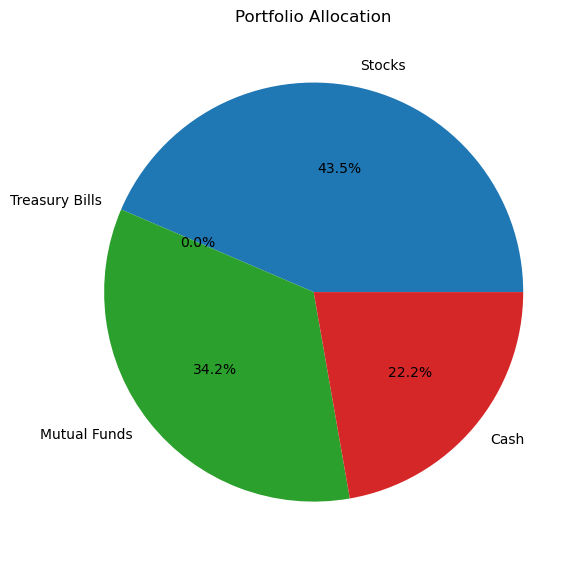

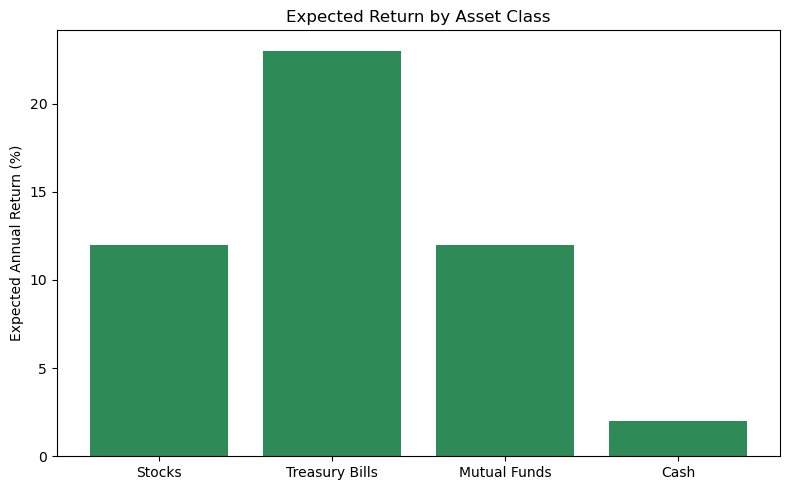

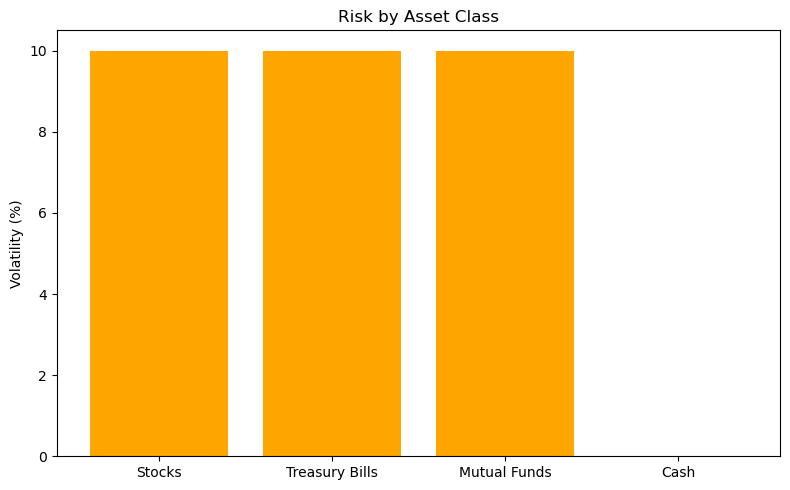

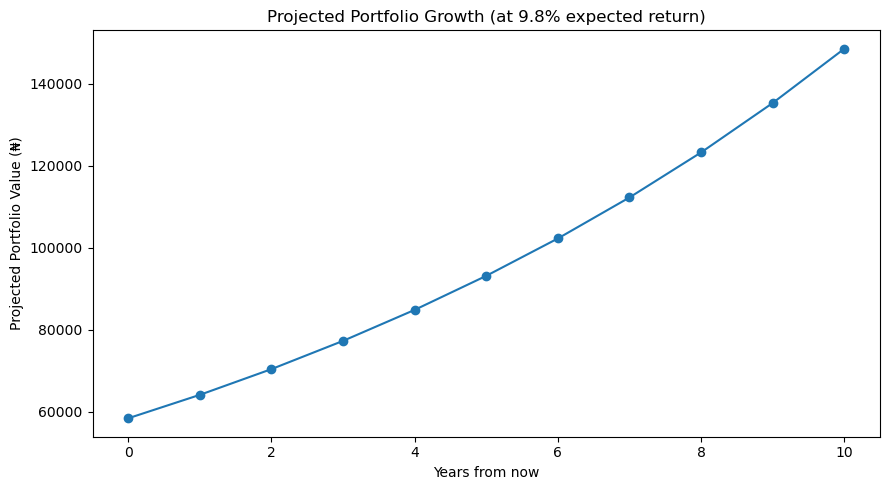

In [9]:
# Charts
def plot_allocation(results):
    weights = results["weights"]
    plt.figure(figsize=(6, 6))
    plt.pie(weights.values(), labels=weights.keys(), autopct="%1.1f%%")
    plt.title("Portfolio Allocation")
    plt.tight_layout()
    plt.show()
 
def plot_returns(data):
    returns = data["returns"]
    plt.figure(figsize=(8, 5))
    plt.bar(returns.keys(), [v * 100 for v in returns.values()], color="seagreen")
    plt.ylabel("Expected Annual Return (%)")
    plt.title("Expected Return by Asset Class")
    plt.tight_layout()
    plt.show()
 
def plot_risk(data):
    vols = data["volatility"]
    plt.figure(figsize=(8, 5))
    plt.bar(vols.keys(), [v * 100 for v in vols.values()], color="orange")
    plt.ylabel("Volatility (%)")
    plt.title("Risk by Asset Class")
    plt.tight_layout()
    plt.show()
 
def plot_growth_projection(results, years=10):
    """Projects portfolio value forward using the blended expected return (a forward projection, since a single client snapshot has no price history)."""
    total_value = results["total_value"]
    expected_return = results["expected_return"]
 
    timeline = list(range(years + 1))
    projected_values = [total_value * (1 + expected_return) ** yr for yr in timeline]
 
    plt.figure(figsize=(9, 5))
    plt.plot(timeline, projected_values, marker="o")
    plt.xlabel("Years from now")
    plt.ylabel("Projected Portfolio Value (₦)")
    plt.title(f"Projected Portfolio Growth (at {expected_return*100:.1f}% expected return)")
    plt.tight_layout()
    plt.show()
 
def generate_charts(data, results):
    plot_allocation(results)
    plot_returns(data)
    plot_risk(data)
    plot_growth_projection(results)
 
def main():
    if os.path.exists(DATA_FILE):
        print(f"Found saved responses in {DATA_FILE} - reusing them (delete the file to re-enter).")
        data = load_client_data()
    else:
        data = collect_client_inputs()
        save_client_data(data)
 
    results = analyze_portfolio(data)
    print_breakdown(data, results)
    print("\n Client Summary ")
    print(build_summary_sentence(data, results))
 
    # Charts are built straight from the same data/results loaded/collected
    generate_charts(data, results)
 
if __name__ == "__main__":
    main()